In [12]:
#%pip install opencv-python --break-system-packages
#%pip install matplotlib --break-system-packages
#%pip install --upgrade numpy opencv-python matplotlib --break-system-packages
#%pip install pandas --break-system-packages

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

%load_ext autoreload
%autoreload 2
import toolbox

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# --- PARTIE I : Test et Validation des Gradients ---

---

Cette section permet de valider la précision des gradients calculés manuellement ($dx$ et $dy$) en les comparant aux versions de référence.

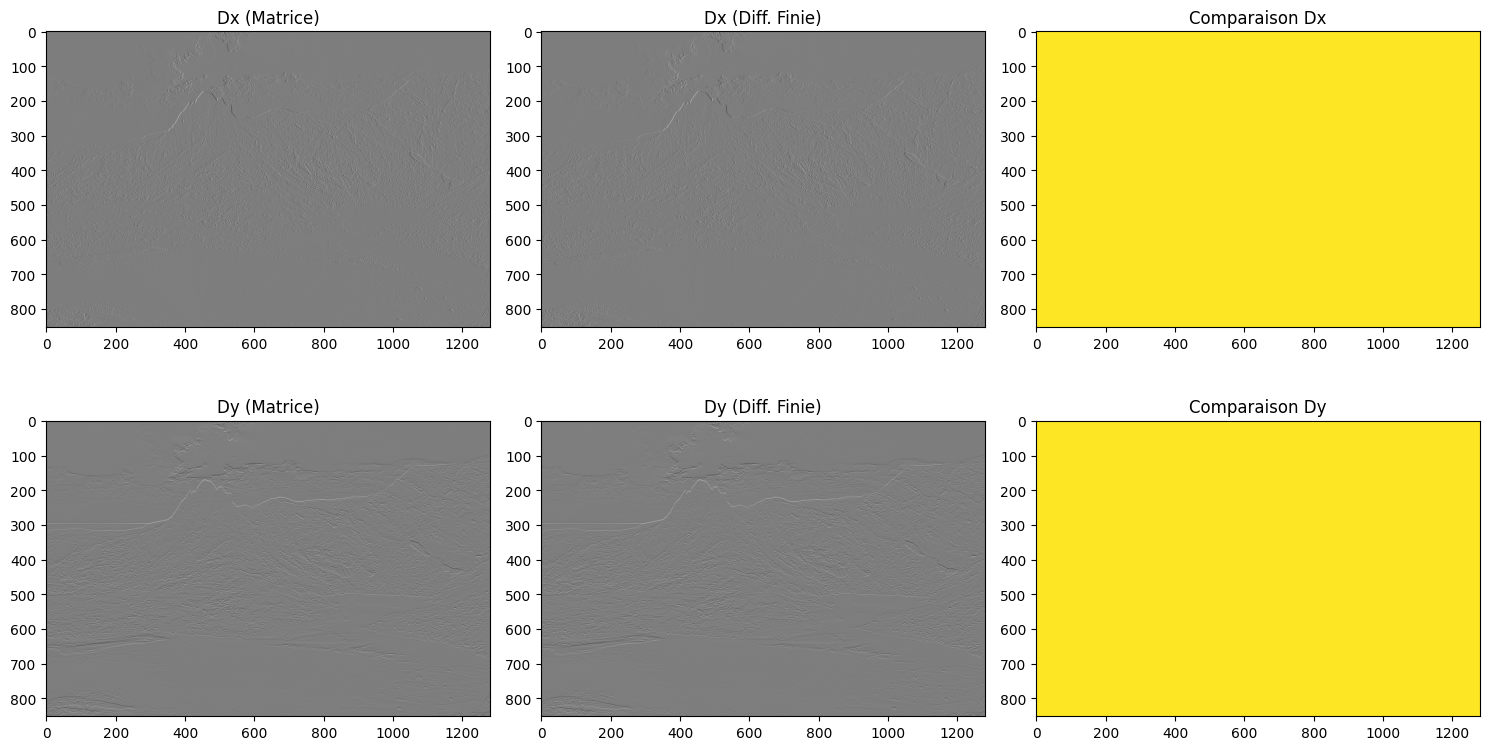

In [14]:
img_bgr = cv2.imread("mountain.jpg")

Dx, Dy = toolbox.build_Dx_Dy(img_bgr)
toolbox.comparer_gradients(img_bgr, Dx, Dy)

# --- PARTIE II : Test et Validation de WLS ---

--- 

In [15]:
img_test = cv2.imread('photo_de_test.png')
img_test_rgb = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB)
img_test_rgb = img_test_rgb.astype(np.float32)/255.0
Dx, Dy = toolbox.build_Dx_Dy(img_test_rgb)

Dx = Dx.tocsr()
Dy = Dy.tocsr()

In [16]:
img_lisse_RGB = toolbox.WLS_RGB(img_test_rgb, Dx, Dy, alpha=1.2, eps=1e-4, lamb=2)

In [17]:
img_lisse_gray = toolbox.WLS_gray(img_test_rgb, Dx, Dy, alpha=1.2, eps=1e-4, lamb=2)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.356924283468337e-16..1.0000082728856743].


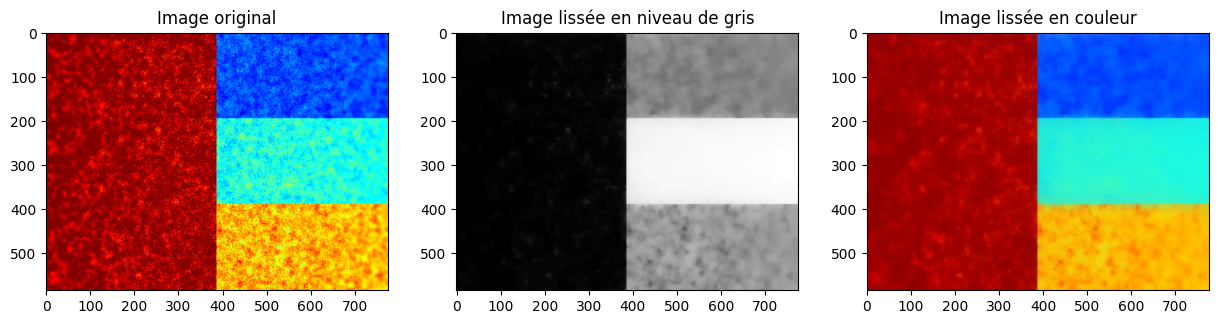

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 8))
axes[0].imshow(img_test_rgb, cmap='gray')
axes[1].imshow(img_lisse_gray, cmap='gray')
axes[2].imshow(img_lisse_RGB)
axes[0].set_title("Image original")
axes[1].set_title("Image lissée en niveau de gris")
axes[2].set_title("Image lissée en couleur")
plt.show()

# --- PARTIE III :  Multi-scale edge-preserving decompositions ---

--- 

In [19]:
img_test = cv2.imread('photo_de_test.png')
img_test_rgb = cv2.cvtColor(img_test, cv2.COLOR_BGR2RGB)
img_test_rgb = img_test_rgb.astype(np.float32)/255.0
n, m, c = img_test.shape
Dx, Dy = toolbox.build_Dx_Dy(img_test_rgb)

Dx = Dx.tocsr()
Dy = Dy.tocsr()

In [20]:
# Lissage itératif
list_lambda = np.linspace(1,20,4)
img_lisse_RGB = np.zeros((n,m,c,4))
for i in range(len(list_lambda)):
    #img_lisse_RGB[:,:,:,i] = toolbox.WLS_RGB(img_test_rgb, Dx, Dy, alpha=1.2, eps=1e-4, lamb=list_lambda[i])
    a = 1


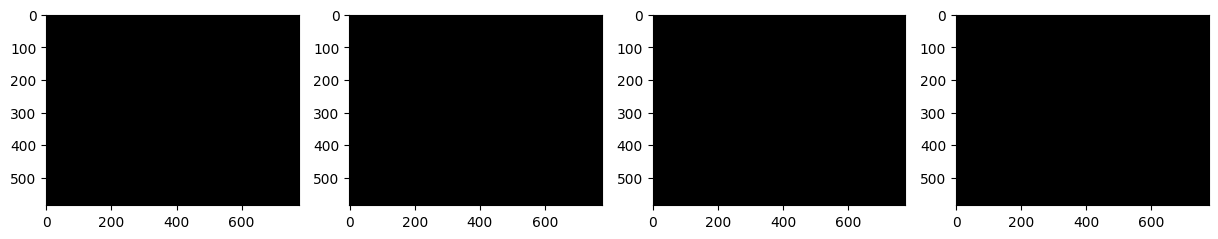

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(15, 40))
axes = axes.flatten()

for i in range(4):
    axes[i].imshow(img_lisse_RGB[:,:,:,i])
    
plt.show()

In [22]:
# Lissage Récursif
list_lambda = np.linspace(1,2,4)
img_lisse_RGB = np.zeros((n,m,c,4))
img_lisse_RGB[:,:,:,0] = toolbox.WLS_RGB(img_test_rgb, Dx, Dy, alpha=1.2, eps=1e-4, lamb=1)

for i in range(len(list_lambda)-1):
    img_intermediaire = img_lisse_RGB[:,:,:,i].copy().astype(np.float32)
    #img_lisse_RGB[:,:,:,i+1] = toolbox.WLS_RGB(img_intermediaire, Dx, Dy, alpha=1.2, eps=1e-4, lamb=list_lambda[i])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.146082651947092e-21..1.000034202749705].


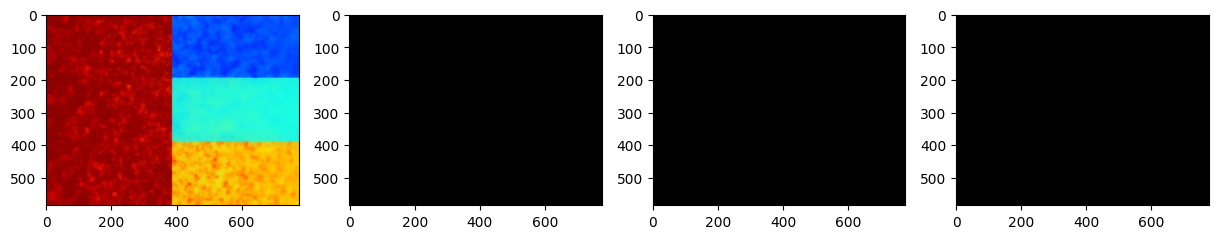

In [23]:
fig, axes = plt.subplots(1, 4, figsize=(15, 40))
axes = axes.flatten()

for i in range(4):
    axes[i].imshow(img_lisse_RGB[:,:,:,i])

plt.show()

# --- PARTIE IV :  Tone-Mapping ---

--- 

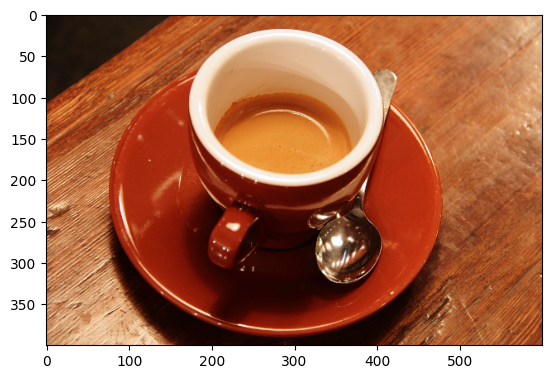

In [24]:
from skimage import data
image = data.coffee()
image = image.astype(np.float32)/255.0

plt.imshow(image)
plt.show()

In [25]:
# Méthode Récursive
base_rec, coarse_rec, medium_rec, fine_rec = toolbox.Tone_Mapping_rec(image)

Text(0.5, 0.98, 'Méthode Récursive')

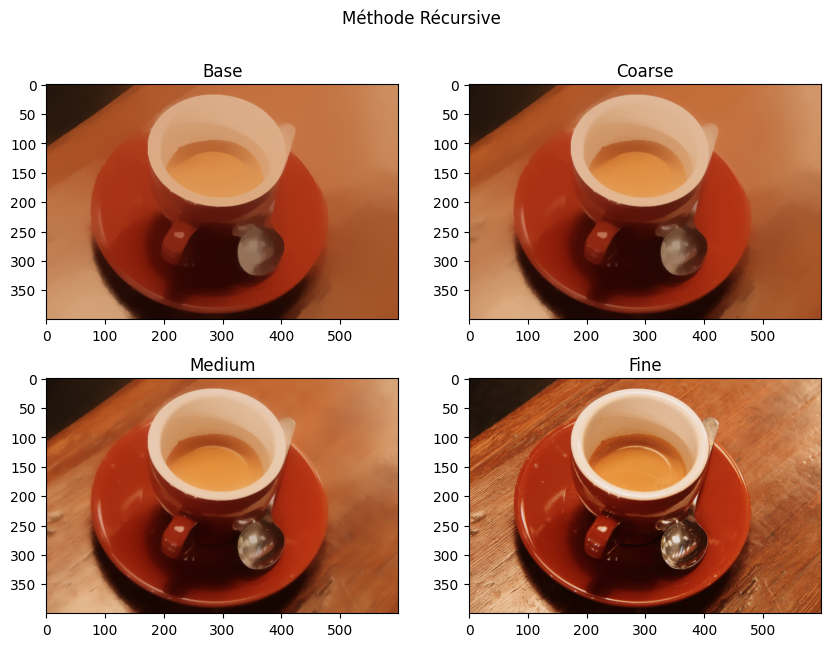

In [26]:
# Affichage d'une méthode
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

axes[0].imshow(base_rec)
axes[0].set_title("Base")
axes[1].imshow(coarse_rec)
axes[1].set_title("Coarse")
axes[2].imshow(medium_rec)
axes[2].set_title("Medium")
axes[3].imshow(fine_rec)
axes[3].set_title("Fine")

fig.suptitle("Méthode Récursive")

In [27]:
# Méthode itérative
list_lamb = [1, 1.5, 2]
base_iter, coarse_iter, medium_iter, fine_iter = toolbox.Tone_Mapping_iter(image, list_lamb)

Text(0.5, 0.98, 'Méthode Itérative')

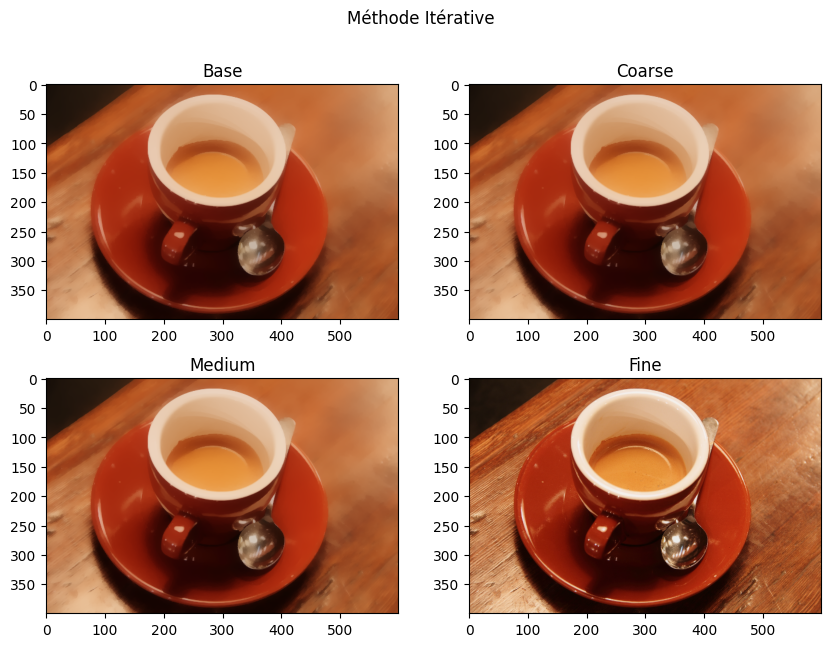

In [28]:
# Affichage d'une méthode
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

axes[0].imshow(base_iter)
axes[0].set_title("Base")
axes[1].imshow(coarse_iter)
axes[1].set_title("Coarse")
axes[2].imshow(medium_iter)
axes[2].set_title("Medium")
axes[3].imshow(fine_iter)
axes[3].set_title("Fine")

fig.suptitle("Méthode Itérative")


In [42]:
import cv2
import numpy as np

def dessiner_contours_noirs(image, chemin_sortie="image_contours.jpg"):

    # 2. Convertir en niveaux de gris (nécessaire pour la détection de contours)
    image_gris = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 3. Appliquer un flou gaussien pour réduire le bruit et améliorer la détection
    flou = cv2.GaussianBlur(image_gris, (5, 5), 0)

    # 4. Détecter les contours avec l'algorithme de Canny
    # Vous pouvez ajuster les seuils (100 et 200) selon vos besoins
    contours_canny = cv2.Canny(flou, 30, 80)

    # 5. Trouver les contours vectoriels à partir de l'image Canny
    contours, _ = cv2.findContours(contours_canny, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 6. Dessiner les contours en noir sur l'image d'origine
    # Le paramètre (0, 0, 0) correspond à la couleur noire en BGR
    # Le dernier paramètre (ici 2) est l'épaisseur du trait en pixels
    image_contours = image.copy()
    cv2.drawContours(image_contours, contours, -1, (0, 0, 0), thickness=2)

    # 7. Sauvegarder et afficher le résultat
    cv2.imwrite(chemin_sortie, image_contours)
    
    # Optionnel : Afficher l'image dans une fenêtre (ne fonctionne pas sur les notebooks sans config)
    cv2.imshow("Contours Noirs", image_contours)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    return image_contours

# --- Exemple d'utilisation ---
base_rec = (base_rec*255).astype(np.uint8)
base_rec = cv2.cvtColor(base_rec, cv2.COLOR_RGB2BGR)
dessiner_contours_noirs(base_rec)

array([[[ 12,  22,  36],
        [ 12,  22,  36],
        [ 12,  22,  36],
        ...,
        [ 96, 142, 205],
        [ 96, 142, 205],
        [ 96, 142, 205]],

       [[ 12,  22,  36],
        [ 12,  22,  36],
        [ 12,  22,  36],
        ...,
        [ 96, 142, 205],
        [ 96, 142, 205],
        [ 96, 142, 205]],

       [[ 12,  22,  36],
        [ 12,  22,  36],
        [ 12,  22,  36],
        ...,
        [ 96, 142, 205],
        [ 96, 142, 205],
        [ 96, 142, 205]],

       ...,

       [[110, 153, 207],
        [110, 153, 207],
        [110, 153, 207],
        ...,
        [ 38,  81, 162],
        [ 38,  81, 162],
        [ 38,  81, 162]],

       [[110, 153, 207],
        [110, 153, 207],
        [110, 153, 207],
        ...,
        [ 38,  81, 162],
        [ 38,  81, 162],
        [ 38,  81, 162]],

       [[110, 153, 207],
        [110, 153, 207],
        [110, 153, 207],
        ...,
        [ 38,  81, 162],
        [ 38,  81, 162],
        [ 38,  81, 162]]